In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

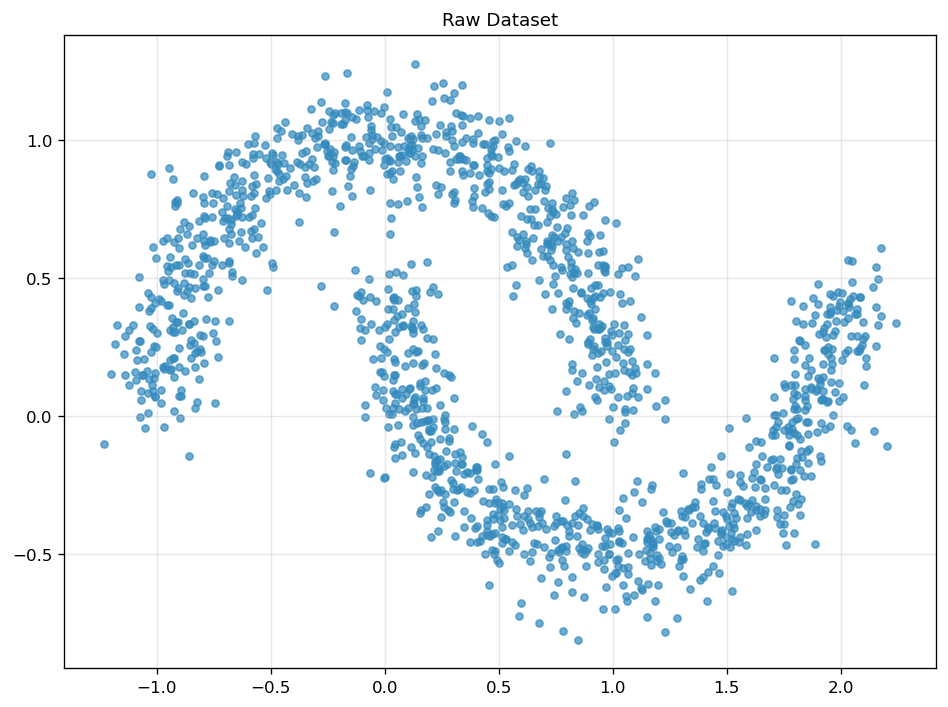

In [29]:
n_samples = 1500
eps = 0.1
X,y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
dbscan = DBSCAN(eps=eps, min_samples=5) # min_sammples: 簇的最小样本点
dbscan.fit(X)

plt.figure(figsize=(8, 6), dpi=120)
plt.scatter(X[:, 0], X[:, 1], c="#348abd", s=18, alpha=0.7)
plt.title("Raw Dataset", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
labels = dbscan.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"检测到簇数量: {n_clusters}")
print(f"噪声样本数量: {n_noise}")

检测到簇数量: 2
噪声样本数量: 21


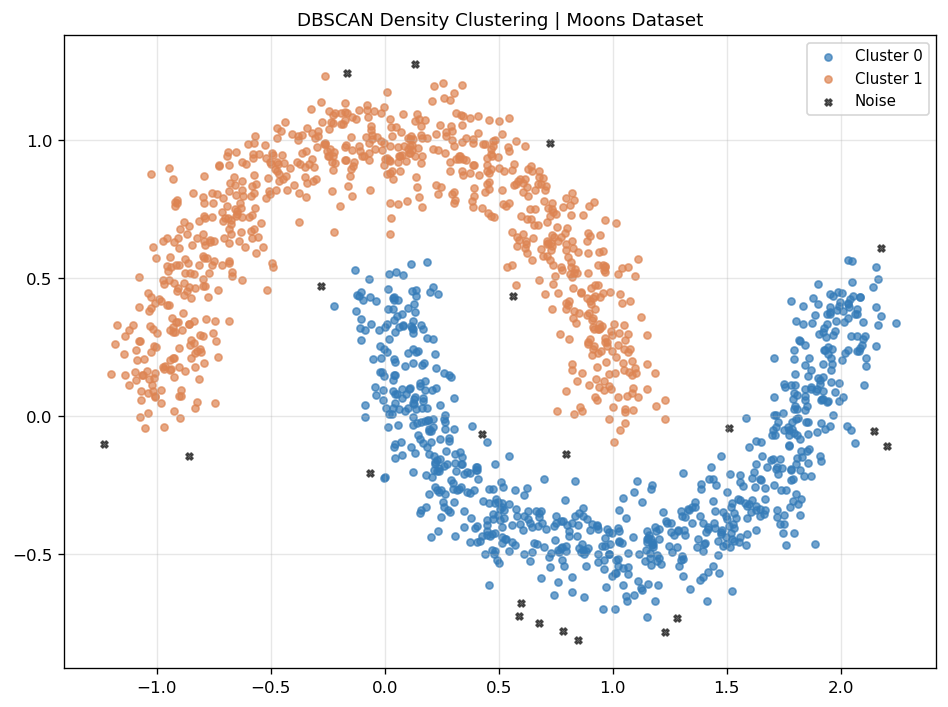

In [31]:
plt.figure(figsize=(8, 6), dpi=120)

palette = [
    "#347bb8",
    "#dd8452",
    "#8470b4",
    "#50a166",
]
noise_color = "black"

unique_labels = set(labels)
for label in unique_labels:
    # 筛选当前簇的样本
    idx = labels == label
    if label == -1:
        # 噪声点
        plt.scatter(X[idx, 0], X[idx, 1], marker="X", c=noise_color, s=18, alpha=0.6, label="Noise")
    else:
        color = palette[label % len(palette)]
        plt.scatter(X[idx, 0], X[idx, 1], c=color, s=18, alpha=0.7, label=f"Cluster {label}")

plt.title("DBSCAN Density Clustering | Moons Dataset", fontsize=11)
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\17934\AppData\Local\Temp\ipykernel_52436\2523361747.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fill = plt.cm.get_cmap("coolwarm", n_clusters)


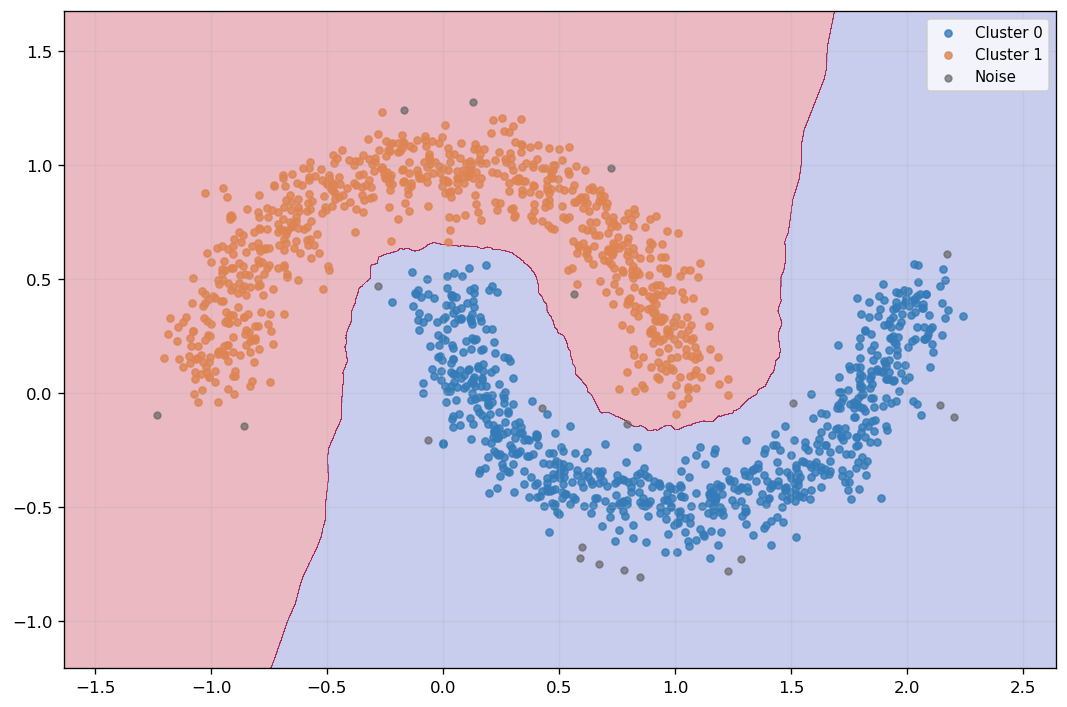

In [32]:
mask_non_noise = labels != -1
X_core = X[mask_non_noise]
label_core = labels[mask_non_noise]

knn_proxy = KNeighborsClassifier(n_neighbors=8)
knn_proxy.fit(X_core, label_core)

# ====================== 生成绘图网格 ======================
h = 0.001
x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 网格上所有点预测簇标签
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn_proxy.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6), dpi=120)

# 绘制聚类区域填充
cmap_fill = plt.cm.get_cmap("coolwarm", n_clusters)
plt.contourf(xx, yy, Z, alpha=0.28, cmap=cmap_fill)

palette = [
    "#347bb8",
    "#dd8452",
]
noise_color = "#666666"

unique_labels = set(labels)
for lab in unique_labels:
    select = labels == lab
    if lab == -1:
        plt.scatter(X[select, 0], X[select, 1], c=noise_color, s=16, alpha=0.7, label="Noise")
    else:
        plt.scatter(X[select, 0], X[select, 1], c=palette[lab], s=18, alpha=0.8, label=f"Cluster {lab}")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

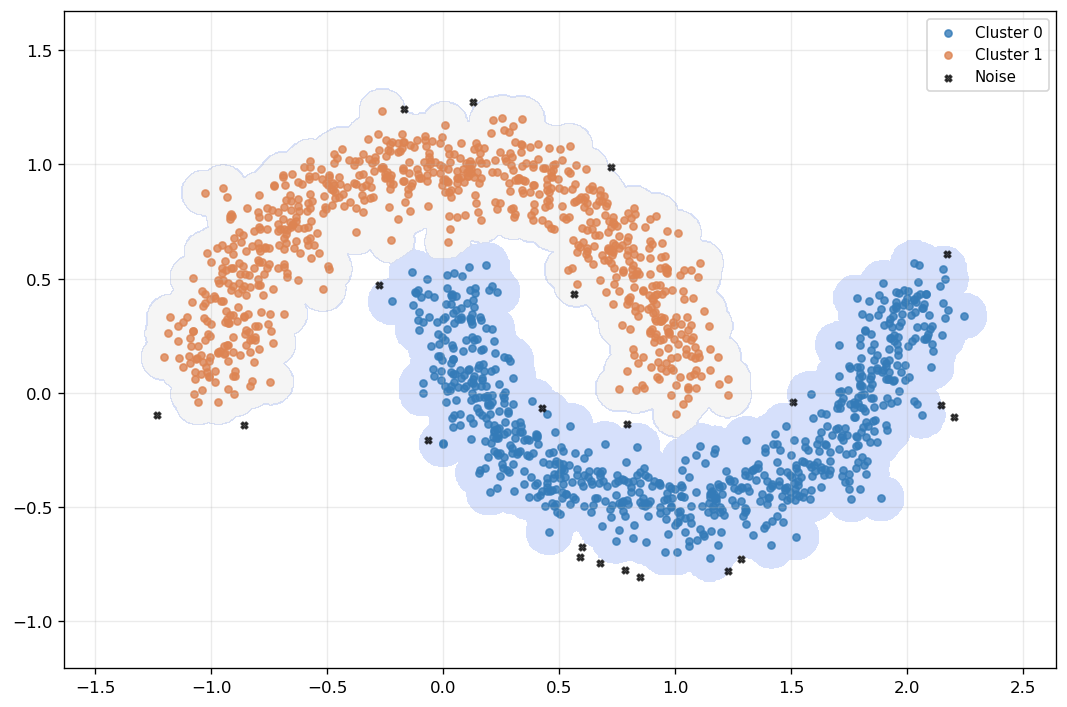

In [34]:
# 分离噪声点与簇内样本
mask_non_noise = labels != -1
X_cluster = X[mask_non_noise]
lab_cluster = labels[mask_non_noise]

n_clusters = len(set(lab_cluster))

# ======================生成网格 ======================
h = 0.005
x_min, x_max = X[:,0].min()-0.4, X[:,0].max()+0.4
y_min, y_max = X[:,1].min()-0.4, X[:,1].max()+0.4
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# 计算每个网格点到所有簇样本的距离
from scipy.spatial import KDTree
tree = KDTree(X_cluster)

# dist: 每个网格点距离最近簇样本的距离
# nearest_idx: 最近样本下标
dist, nearest_idx = tree.query(grid, k=1)

Z = np.full(grid.shape[0], -2)
inside_mask = dist <= eps
Z[inside_mask] = lab_cluster[nearest_idx[inside_mask]]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9,6), dpi=120)

cmap = plt.cm.coolwarm
contour = plt.contourf(xx, yy, Z, levels=[-1,0,1,2], alpha=0.28, cmap=cmap)

unique_labels = set(labels)

for lab in unique_labels:
    select = labels == lab
    if lab == -1:
        plt.scatter(X[select,0], X[select,1], marker="X", c="black", s=16, alpha=0.7, label="Noise")
    elif lab ==0:
        plt.scatter(X[select,0], X[select,1], c="#347bb8", s=18, alpha=0.8, label=f"Cluster 0")
    else:
        plt.scatter(X[select,0], X[select,1], c="#dd8452", s=18, alpha=0.8, label=f"Cluster 1")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
